In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

In [18]:
df_latest = pd.read_csv("resultats_complets_latest.csv")
df_lesions = pd.read_csv("resultats_complets_lesion.csv")

# Évaluation de la Précision Globale et par Catégorie

## LGG vs HGG
L’idée est de visualiser la performance du modèle via des boxplots, ce qui permet de comparer la médiane, la dispersion et les valeurs extrêmes du Dice entre les deux groupes.

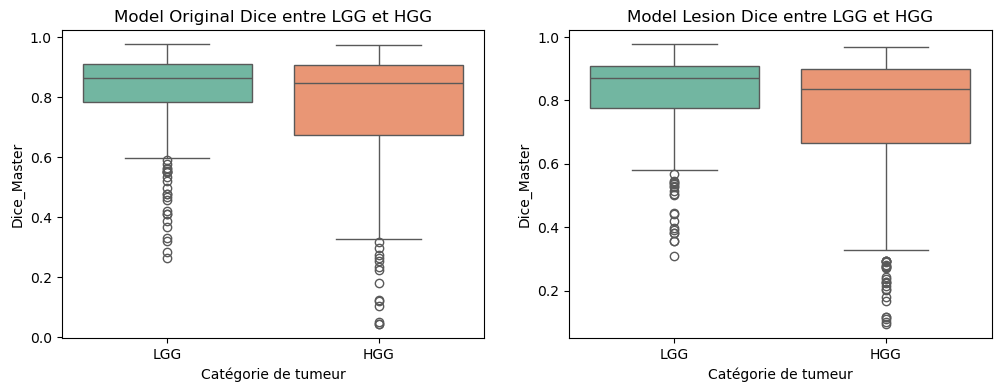

In [ ]:
df_plot1 = df_latest[["Catégorie", "Dice_Master"]] # Créer les boxplots 
df_plot2 = df_lesions[["Catégorie", "Dice_Master"]] # Créer les boxplots 

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.boxplot(
    x="Catégorie", 
    y="Dice_Master", 
    hue="Catégorie",          # on associe la palette à la variable
    data=df_plot1, 
    palette="Set2", 
    legend=False              # pour éviter une légende redondante
)

plt.title("Model Original Dice entre LGG et HGG")
plt.ylabel("Dice_Master")
plt.xlabel("Catégorie de tumeur")

plt.subplot(1,2,2)
sns.boxplot(
    x="Catégorie", 
    y="Dice_Master", 
    hue="Catégorie",          # on associe la palette à la variable
    data=df_plot2, 
    palette="Set2", 
    legend=False              # pour éviter une légende redondante
)

plt.title("Model Lesion Dice entre LGG et HGG")
plt.ylabel("Dice_Master")
plt.xlabel("Catégorie de tumeur")
plt.show()

# Modalitée : T1ce vs FLAIR vs T2

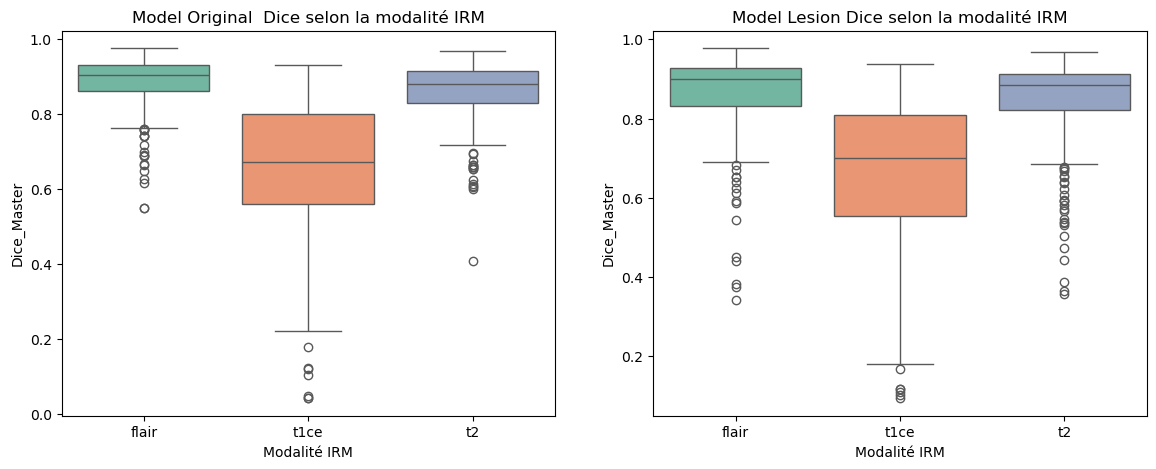

In [ ]:
# Filtrer les colonnes utiles
df_plot1 = df_latest[["Modalité", "Dice_Master"]]
df_plot2 = df_lesions[["Modalité", "Dice_Master"]]

# Créer les boxplots par modalité
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.boxplot(
    x="Modalité", 
    y="Dice_Master", 
    hue="Modalité",        # associer la palette aux modalités
    data=df_plot1, 
    palette="Set2", 
    legend=False
)
plt.title("Model Original Dice selon la modalité IRM")
plt.ylabel("Dice_Master")
plt.xlabel("Modalité IRM")

plt.subplot(1,2,2)
sns.boxplot(
    x="Modalité", 
    y="Dice_Master", 
    hue="Modalité",        # associer la palette aux modalités
    data=df_plot2, 
    palette="Set2", 
    legend=False
)

plt.title("Model Liesion Dice selon la modalité IRM")
plt.ylabel("Dice_Master")
plt.xlabel("Modalité IRM")
plt.show()


In [14]:
import pandas as pd
from scipy.stats import mannwhitneyu, kruskal


# --- Test LGG vs HGG ---
lgg = df_latest[df_latest["Catégorie"]=="LGG"]["Dice_Master"]
hgg = df_latest[df_latest["Catégorie"]=="HGG"]["Dice_Master"]

stat_lgg_hgg, pval_lgg_hgg = mannwhitneyu(lgg, hgg, alternative="two-sided")
print("Mann-Whitney LGG vs HGG: stat=%.3f, p=%.4f" % (stat_lgg_hgg, pval_lgg_hgg))

# --- Test Modalités ---
modalities = [df_latest[df_latest["Modalité"]==m]["Dice_Master"] for m in df_latest["Modalité"].unique()]
stat_mod, pval_mod = kruskal(*modalities)
print("Kruskal-Wallis Modalités: stat=%.3f, p=%.4f" % (stat_mod, pval_mod))

Mann-Whitney LGG vs HGG: stat=115234.000, p=0.0003
Kruskal-Wallis Modalités: stat=402.560, p=0.0000


In [16]:
import pandas as pd
from statsmodels.stats.multicomp import pairwise_tukeyhsd


# Test ANOVA préalable (si normalité et homogénéité des variances sont OK)
# Puis Tukey HSD
tukey = pairwise_tukeyhsd(endog=df_latest["Dice_Master"], groups=df_latest["Modalité"], alpha=0.05)

print(tukey)


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
 flair   t1ce  -0.2342    0.0 -0.2576 -0.2108   True
 flair     t2  -0.0241 0.0418 -0.0475 -0.0007   True
  t1ce     t2   0.2101    0.0  0.1867  0.2335   True
----------------------------------------------------


# Analyse des prompts

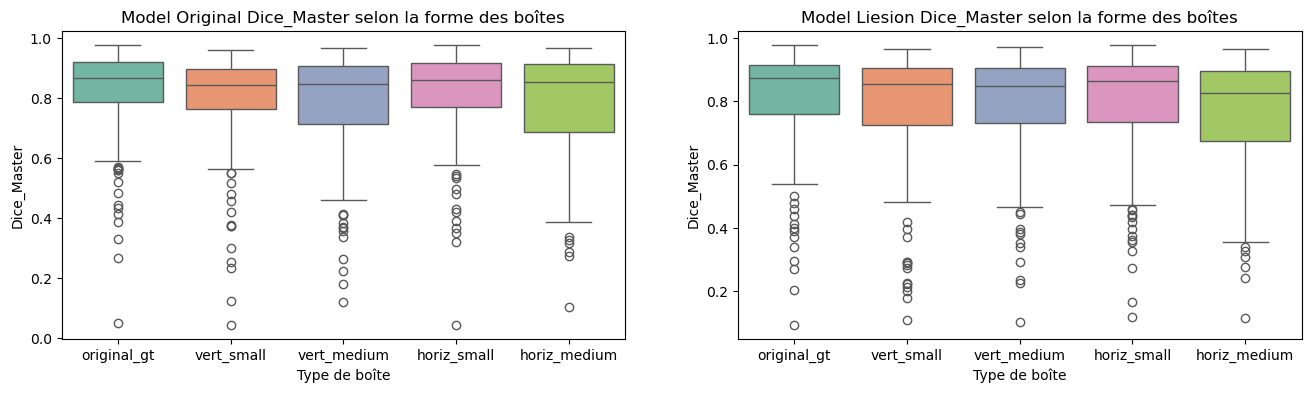

In [63]:
# Filtrer les colonnes utiles
df_plot1 = df_latest[["TypeBox", "Dice_Master"]]
df_plot2 = df_lesions[["TypeBox", "Dice_Master"]]

# Boxplots
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
sns.boxplot(
    x="TypeBox", 
    y="Dice_Master", 
    hue="TypeBox", 
    data=df_plot1, 
    palette="Set2", 
    legend=False
)
plt.title("Model Original Dice_Master selon la forme des boîtes")
plt.ylabel("Dice_Master")
plt.xlabel("Type de boîte")

plt.subplot(1,2,2)
sns.boxplot(
    x="TypeBox", 
    y="Dice_Master", 
    hue="TypeBox", 
    data=df_plot2, 
    palette="Set2", 
    legend=False
)
plt.title("Model Liesion Dice_Master selon la forme des boîtes")
plt.ylabel("Dice_Master")
plt.xlabel("Type de boîte")

plt.show()


# Test statistique Mann-Whitney
box_types = ["vert_medium", "horiz_medium", "vert_small", "horiz_small"]
box_result_original = {}
box_result_liesion = {}

original1 = df_latest[df_latest["TypeBox"]=="original_gt"]["Dice_Master"]
original2 = df_lesions[df_lesions["TypeBox"]=="original_gt"]["Dice_Master"]

for bbox in box_types:
    data_box_type1 = df_latest[df_latest["TypeBox"]==bbox]["Dice_Master"]
    data_box_type2 = df_lesions[df_lesions["TypeBox"]==bbox]["Dice_Master"]

    _, pval1 = mannwhitneyu(original1, data_box_type1, alternative="two-sided")
    _, pval2 = mannwhitneyu(original2, data_box_type2, alternative="two-sided")
    box_result_original[bbox] = pval1
    box_result_liesion[bbox] = pval2

In [34]:
[box_result_liesion, box_result_original]

[{'vert_medium': 0.10466206134088152,
  'horiz_medium': 0.0007602700873779523,
  'vert_small': 0.08218781721734124,
  'horiz_small': 0.4062135026052005},
 {'vert_medium': 0.039327983492643416,
  'horiz_medium': 0.12854817714667033,
  'vert_small': 0.015485409709265596,
  'horiz_small': 0.5833597888207046}]

# Fidélité Volumétrique et Propagation


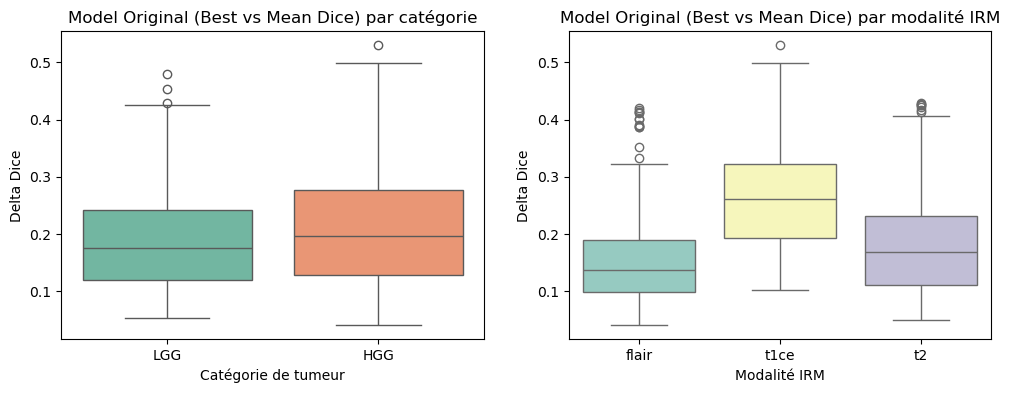

In [61]:
# Calcul du drift
df_latest["Delta_Dice"] = df_latest["Best_Slice_Dice"] - df_latest["Mean_Dice_Vol"]

# Boxplot par catégorie
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.boxplot(x="Catégorie", y="Delta_Dice", data=df_latest, hue="Catégorie", palette="Set2")
plt.title("Model Original (Best vs Mean Dice) par catégorie")
plt.ylabel("Delta Dice")
plt.xlabel("Catégorie de tumeur")

# Boxplot par modalité
plt.subplot(1,2,2)
sns.boxplot(x="Modalité", y="Delta_Dice", data=df_latest, hue="Modalité", palette="Set3")
plt.title("Model Original (Best vs Mean Dice) par modalité IRM")
plt.ylabel("Delta Dice")
plt.xlabel("Modalité IRM")
plt.show()

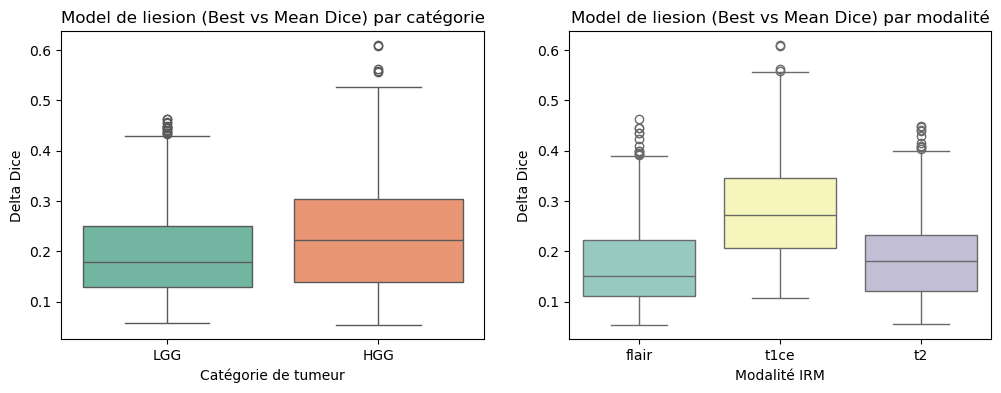

In [60]:
# Calcul du drift
df_lesions["Delta_Dice"] = df_lesions["Best_Slice_Dice"] - df_lesions["Mean_Dice_Vol"]

# Boxplot par catégorie
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.boxplot(x="Catégorie", y="Delta_Dice", data=df_lesions, hue="Catégorie", palette="Set2")
plt.title("Model de liesion (Best vs Mean Dice) par catégorie")
plt.ylabel("Delta Dice")
plt.xlabel("Catégorie de tumeur")

# Boxplot par modalité
plt.subplot(1,2,2)
sns.boxplot(x="Modalité", y="Delta_Dice", data=df_lesions, hue="Modalité", palette="Set3")
plt.title("Model de liesion (Best vs Mean Dice) par modalité")
plt.ylabel("Delta Dice")
plt.xlabel("Modalité IRM")
plt.show()

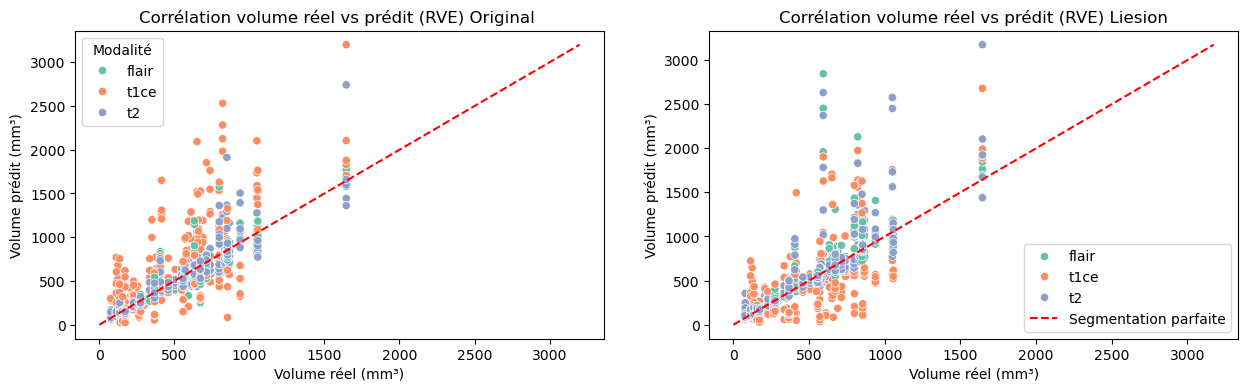

In [59]:
# Scatter plot volume réel vs prédit
plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
sns.scatterplot(
    x="volume_tumeur", 
    y="volume_tumeur_predict", 
    hue="Modalité",   # ou "Modalité" pour comparer par IRM
    data=df_latest, 
    palette="Set2"
)

# Ajouter la diagonale y=x
max_val = max(df_latest["volume_tumeur"].max(), df_latest["volume_tumeur_predict"].max())
plt.plot([0, max_val], [0, max_val], 'r--', label="Segmentation parfaite")

plt.title("Corrélation volume réel vs prédit (RVE) Original ")
plt.xlabel("Volume réel (mm³)")
plt.ylabel("Volume prédit (mm³)")

plt.subplot(1,2,2)
sns.scatterplot(
    x="volume_tumeur", 
    y="volume_tumeur_predict", 
    hue="Modalité",   # ou "Modalité" pour comparer par IRM
    data=df_lesions, 
    palette="Set2"
)

# Ajouter la diagonale y=x
max_val = max(df_lesions["volume_tumeur"].max(), df_lesions["volume_tumeur_predict"].max())
plt.plot([0, max_val], [0, max_val], 'r--', label="Segmentation parfaite")

plt.title("Corrélation volume réel vs prédit (RVE) Liesion")
plt.xlabel("Volume réel (mm³)")
plt.ylabel("Volume prédit (mm³)")
plt.legend()

plt.legend()
plt.show()


In [62]:
print("Corrélation volume predict vs volume reel:", df_latest["volume_tumeur"].corr(df_latest["volume_tumeur_predict"]))
print("Corrélation volume predict vs volume reel:", df_lesions["volume_tumeur"].corr(df_lesions["volume_tumeur_predict"]))

Corrélation volume predict vs volume reel: 0.8155367646067504
Corrélation volume predict vs volume reel: 0.7659999519272365


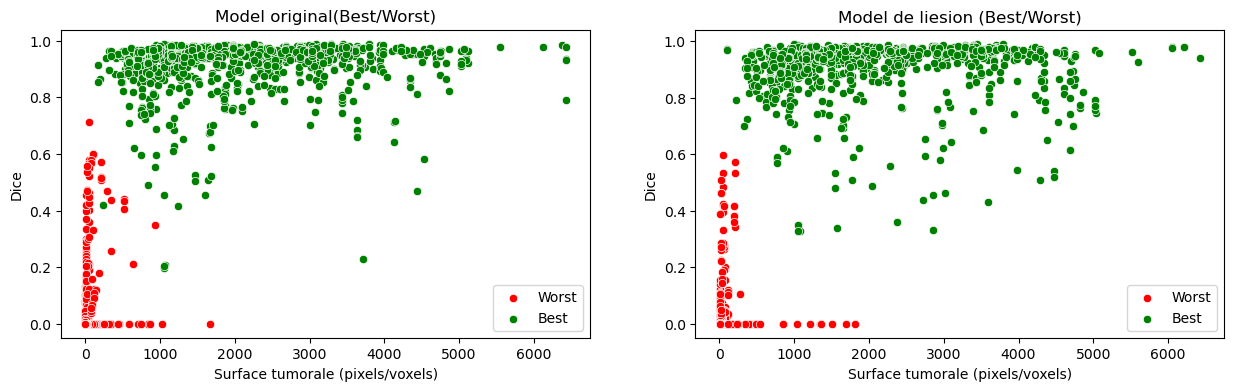

In [ ]:
plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
sns.scatterplot(x="Worst_Surface", y="Worst_Slice_Dice", data=df_latest, color="red", label="Worst")
sns.scatterplot(x="Best_Surface", y="Best_Slice_Dice", data=df_latest, color="green", label="Best")
plt.title("Model original(Best/Worst)")
plt.xlabel("Surface tumorale (pixels/voxels)")
plt.ylabel("Dice")

plt.subplot(1,2,2)
sns.scatterplot(x="Worst_Surface", y="Worst_Slice_Dice", data=df_lesions, color="red", label="Worst")
sns.scatterplot(x="Best_Surface", y="Best_Slice_Dice", data=df_lesions, color="green", label="Best")
plt.title("Model de liesion (Best/Worst)")
plt.xlabel("Surface tumorale (pixels/voxels)")
plt.ylabel("Dice")
plt.legend()
plt.show()

In [ ]:
print("Corrélation Worst_Surface vs Worst_Slice_Dice:", df_latest["Worst_Surface"].corr(df_latest["Worst_Slice_Dice"]))
print("Corrélation Best_Surface vs Best_Slice_Dice:", df_latest["Best_Surface"].corr(df_latest["Best_Slice_Dice"]))

Corrélation Worst_Surface vs Worst_Slice_Dice: 0.13970318128080725
Corrélation Best_Surface vs Best_Slice_Dice: 0.10405006067431283
